In [115]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import attrs

import eradiate
eradiate.set_mode("mono_polarized")

from eradiate.units import unit_registry as ureg
from eradiate.scenes.geometry import SphericalShellGeometry, EARTH_RADIUS, WrapMode
from eradiate.scenes.atmosphere import ParticleLayer, ParticleField
from eradiate.grid import SphericalShellGridCoords
from eradiate.experiments import AtmosphereExperiment
from eradiate.scenes.bsdfs import LambertianBSDF
from eradiate.scenes.measure import PerspectiveCameraMeasure
from eradiate.spectral import MonoSpectralIndex, DeltaSRF
from eradiate.scenes.integrators import EOVolPathIntegrator
from eradiate.scenes.illumination import DirectionalIllumination

In [2]:
integrator = EOVolPathIntegrator(
    stokes=False,
    moment=False, 
    max_depth=30,
) # We are testing the 3D spherical features, not the correctness or performances
integrator

EOVolPathIntegrator(id='integrator', timeout=None, moment=False, stokes=False, meridian_align=True, max_depth=50, hide_emitters=None, rr_depth=1000, rr_factor=0.97, ddis_threshold=0.1)

# Checkerboard example

In [3]:
si = MonoSpectralIndex(550*ureg.nm)

In [4]:
nlon, nlat = 5, 9

In [5]:
toa = 1.0 * ureg.km

In [6]:
grid = SphericalShellGridCoords(
    levels=np.linspace(0, toa.m_as("km"), 2) * ureg.km,
    colatitudes=np.linspace(50, 130, nlat + 1) * ureg.degree,
    azimuths=np.linspace(-20, 20, nlon + 1) * ureg.degree,
)
grid

SphericalShellGridCoords(
  azimuth:    [-20.0 deg, 20.0 deg], 5 sectors
  colatitude: [50.0 deg, 130.0 deg], 9 bands
  z:          [0.0 km, 1.0 km], 1 layers
)

In [7]:
geometry = SphericalShellGeometry(
    grid=grid,
    toa_altitude=toa,
    planet_radius=50*ureg.km
)
geometry

SphericalShellGeometry(toa_altitude=1.0 km, ground_altitude=0.0 km, grid=SphericalShellGridCoords(
  azimuth:    [-20.0 deg, 20.0 deg], 5 sectors
  colatitude: [50.0 deg, 130.0 deg], 9 bands
  z:          [0.0 km, 1.0 km], 1 layers
), filter_type=<FilterType.NEAREST: 1>, wrap_mode=<WrapMode.CLAMP: 0>, planet_radius=50 km)

In [8]:
camera = PerspectiveCameraMeasure(
    origin = [300, 0, 0] * ureg.km,
    target = [100, 0, 1e-3] * ureg.km,
    film_resolution=(256,256),
)
camera

PerspectiveCameraMeasure(id='measure', mi_results={}, srf=DeltaSRF(wavelengths=[550.] nm), sampler='independent', rfilter='box', spp=32, _film_resolution=(256, 256), origin=[300   0   0] km, target=[100.0 0.0 0.001] km, up=array([0, 0, 1]), far_clip=10000.0 km, fov=50.0 deg)

In [9]:
tau_ref = np.indices((nlon, nlat)).sum(axis=0) % 2 * 0.8

In [10]:
particles = ParticleLayer(
    geometry=geometry,
    tau_ref=tau_ref,
    bottom=grid.levels[0],
    top=grid.levels[-1],
    # extremum_resolution=(1,1,9), # Not implemented yet
)
particles

ParticleLayer(id='atmosphere', geometry=SphericalShellGeometry(toa_altitude=1.0 km, ground_altitude=0.0 km, grid=SphericalShellGridCoords(
  azimuth:    [-20.0 deg, 20.0 deg], 5 sectors
  colatitude: [50.0 deg, 130.0 deg], 9 bands
  z:          [0.0 km, 1.0 km], 1 layers
), filter_type=<FilterType.NEAREST: 1>, wrap_mode=<WrapMode.CLAMP: 0>, planet_radius=50 km), use_rrt=True, scale=None, force_majorant=False, extremum_resolution=(1, 1, 1), bottom=0.0 km, top=1.0 km, distribution=UniformParticleDistribution(bounds=array([0., 1.])), w_ref=550.0 nm, tau_ref=[[0.0 0.8 0.0 0.8 0.0 0.8 0.0 0.8 0.0] [0.8 0.0 0.8 0.0 0.8 0.0 0.8 0.0 0.8] [0.0 0.8 0.0 0.8 0.0 0.8 0.0 0.8 0.0] [0.8 0.0 0.8 0.0 0.8 0.0 0.8 0.0 0.8] [0.0 0.8 0.0 0.8 0.0 0.8 0.0 0.8 0.0]], dataset=<xarray.Dataset | source='/home/miskn/.cache/eradiate/installed/eradiate-v1.2.0.dev0/aerosol/govaerts_2021-continental.nc'>, has_absorption=True, has_scattering=True, force_polarized_phase=False, particle_shape='spherical', _phase=Tabulat

In [11]:
exp = AtmosphereExperiment(
    geometry=geometry,
    measures=camera,
    atmosphere=particles,
    surface=LambertianBSDF(reflectance=0.2),
    integrator=integrator,
    illumination=DirectionalIllumination(zenith=90*ureg.degree)
    
)

In [12]:
particles.distribution(1.5)

array(0.)

In [17]:
%%time
res = eradiate.run(exp, spp=100)

CPU times: user 7.32 s, sys: 1.92 ms, total: 7.32 s
Wall time: 792 ms


In [18]:
geometry.bbox

BoundingBox(min=[-51000.0 -51000.0 -51000.0] m, max=[51000.0 51000.0 51000.0] m)

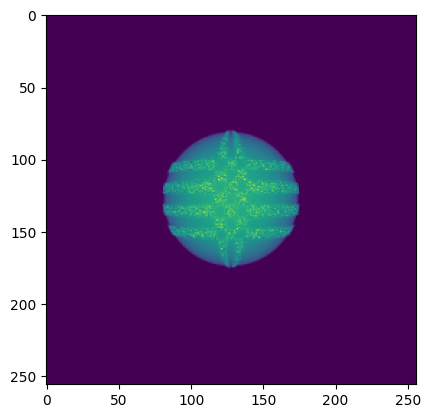

In [19]:
plt.imshow(res.radiance.squeeze())

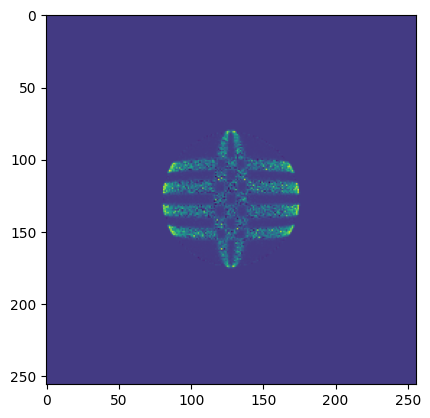

In [20]:
res_noatm = eradiate.run(attrs.evolve(exp, atmosphere=None), )
plt.imshow(res.radiance.squeeze() - res_noatm.radiance.squeeze())

# C3 Spherical

In [21]:
toa = 2 * ureg.km

resolution = 670  # m
d_angle = resolution / EARTH_RADIUS.m_as("meter")

nlat, nlon = 100, 100

half_lon = nlon / 2 * d_angle
half_lat = nlat / 2 * d_angle

azimuths    = np.linspace(-half_lon, half_lon, nlon + 1) * ureg.rad
colatitudes = np.linspace(np.pi/2 - half_lat, np.pi/2 + half_lat, nlat + 1) * ureg.rad

In [65]:
grid = SphericalShellGridCoords(
    levels=np.linspace(0, toa.m_as("km"), 101) * ureg.km,
    colatitudes=colatitudes.to("degree"),
    azimuths=azimuths.to("degree"),
)
grid

SphericalShellGridCoords(
  azimuth:    [-0.3009373659378589 deg, 0.3009373659378589 deg], 100 sectors
  colatitude: [89.69906263406213 deg, 90.30093736593787 deg], 100 bands
  z:          [0.0 km, 2.0 km], 100 layers
)

In [130]:
geometry = SphericalShellGeometry(
    grid=grid,
    toa_altitude=toa,
    planet_radius=EARTH_RADIUS,
    wrap_mode=WrapMode.MIRROR,
)
geometry

SphericalShellGeometry(toa_altitude=2 km, ground_altitude=0.0 km, grid=SphericalShellGridCoords(
  azimuth:    [-0.3009373659378589 deg, 0.3009373659378589 deg], 100 sectors
  colatitude: [89.69906263406213 deg, 90.30093736593787 deg], 100 bands
  z:          [0.0 km, 2.0 km], 100 layers
), filter_type=<FilterType.NEAREST: 1>, wrap_mode=<WrapMode.MIRROR: 2>, planet_radius=6378.1 km)

In [131]:
def load_extinction_profile(cumulus_path, w, v_eff=1 / 9):
    
    """
    Read the cumulus .dat file and return cumulus_profile (xr.Dataset).
    This function support IPRT extinction profiles
    """
    
    import pandas as pd

    df = pd.DataFrame(
        data=np.loadtxt(cumulus_path, skiprows=3),
        columns=["i_x", "i_y", "i_z", "extinction", "r_eff"],
    )
    df[["i_x", "i_y", "i_z"]] = df[["i_x", "i_y", "i_z"]].astype(int) - 1
    n_x, n_y, n_z = np.loadtxt(cumulus_path, skiprows=1, max_rows=1, usecols=(0, 1, 2))
    x_r, y_r = np.loadtxt(cumulus_path, skiprows=2, max_rows=1, usecols=(0, 1))
    z_levels = np.loadtxt(cumulus_path, skiprows=2, max_rows=1)[2:]
    df["v_eff"] = float(v_eff)
    ext = df.extinction
    df = df.drop("extinction", axis=1)
    ds1 = df.to_xarray()

    ds2 = xr.Dataset(
        coords=dict(
            x=(["x"], np.arange(0, n_x + 1, 1, dtype=int)),
            y=(["y"], np.arange(0, n_y + 1, 1, dtype=int)),
            z=(["z"], np.arange(0, n_z + 1, 1, dtype=int)),
        ),
        data_vars=dict(
            x_levels=(
                ["x"],
                np.arange(0, x_r * n_x * 1.01, x_r),
                dict(units="km"),
            ),
            y_levels=(
                ["y"],
                np.arange(0, y_r * n_y * 1.01, y_r),
                dict(units="km"),
            ),
            z_levels=(["z"], z_levels, dict(units="km")),
        ),
    )

    ext.index.name = "index"
    ext = ext.to_frame()
    ext["w"] = w.m_as("nm")
    ext = ext.set_index("w", append=True)
    ds3 = ext.to_xarray()

    ds = xr.merge(
        [
            ds1,
            ds2,
            ds3,
        ]
    )
   
    ds.w.attrs["units"] = "nanometer"
    ds.extinction.attrs["units"] = "1/kilometer"
    ds.r_eff.attrs["units"] = "micron"
    ds.v_eff.attrs["units"] = "micron ** 2"

    return ds

In [132]:
cu_profile = load_extinction_profile("test_3d_clouds/cumulus.dat", 670 * ureg.nm)

In [133]:
mie_ws = xr.load_dataset("test_3d_clouds/watercloud_670.mie.cdf")

In [134]:
from eradiate.scenes.atmosphere import format_particles_dataset
wc_ds = format_particles_dataset(mie_ws, [1 / 9])

In [135]:
def extend_profile_lwc(profile, properties, method="linear"):

    r_eff = profile.r_eff
    v_eff = profile.v_eff
    mass_ext = properties.m_extinction.interp(r_eff=r_eff, v_eff=v_eff, method=method)
    mass_ext = mass_ext.assign_coords(
        w=eradiate.units.to_quantity(mass_ext.w).m_as(profile.w.units)
    )
    mass_density = eradiate.units.to_quantity(profile.extinction).T / eradiate.units.to_quantity(mass_ext)
    assert np.allclose(np.abs(mass_density.m - mass_density.m[0]), 0.0)
    
    profile_extended = profile.copy()
    u = str(mass_density.units)
    profile_extended["mass_density"] = (["index"], mass_density.m_as(u)[0])
    profile_extended["mass_density"].attrs["units"] = str(u)

    return profile_extended

cu_profile_lwc = extend_profile_lwc(cu_profile, wc_ds)

In [ ]:
# artificially remove the contour cells, useful for wrap_mode=clamp, but optional
cu_profile_cropped = cu_profile_lwc.sel(index=~cu_profile_lwc.i_x.isin([0, 99]) & ~cu_profile_lwc.i_y.isin([0, 99]))

In [164]:
cfield = ParticleField(
    profile=cu_profile_cropped,
    properties=mie_ws,
    z_interp_method="nearest",
    geometry=geometry,
)

In [220]:
camera = PerspectiveCameraMeasure(
    origin = [EARTH_RADIUS.m_as("km") + 200, -250, 100] * ureg.km,
    target = [EARTH_RADIUS.m_as("km") + 50, 0, 1e-3] * ureg.km,
    film_resolution=(256, 256),
    srf=DeltaSRF(670*ureg.nm)
)
camera

PerspectiveCameraMeasure(id='measure', mi_results={}, srf=DeltaSRF(wavelengths=[670.] nm), sampler='independent', rfilter='box', spp=32, _film_resolution=(128, 128), origin=[6578.1 -250.0 100.0] km, target=[6428.1 0.0 0.001] km, up=array([0, 0, 1]), far_clip=10000.0 km, fov=50.0 deg)

In [221]:
exp = AtmosphereExperiment(
    geometry=geometry,
    measures=camera,
    atmosphere=cfield,
    surface=LambertianBSDF(reflectance=0.2),
    integrator=integrator,
    illumination=DirectionalIllumination(zenith=20*ureg.degree, azimuth=0*ureg.degree)
)

In [ ]:
%%time

import drjit as dr
dr.set_thread_count(20)

res = eradiate.run(exp, spp=400)

/home/miskn/git/erd_multi/src/eradiate/scenes/atmosphere/_particle_field.py:913: UserWarning: Profile has Cartesian coordinates (x/y) but target grid is a SphericalShellGridCoords. Assuming equatorial Mercator projection. Proceeding anyway.
  warnings.warn(


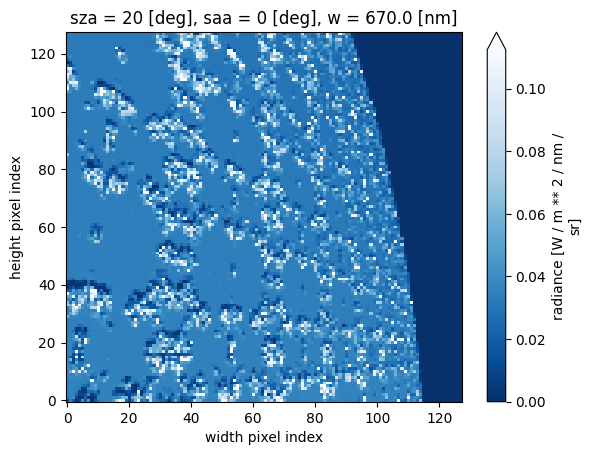

In [227]:
res.squeeze().radiance.plot(robust=True, cmap="Blues_r")